# Stock Market Analysis & Prediction using LSTM

**Stocks Analyzed:** Apple, Google, Microsoft, Amazon, Tesla, Nvidia, Meta.
**Data Source:** Yahoo Finance via yfinance
**Time Period:** Last 10 years
**Prediction Target:** Apple(AAPL) Closing Price using LSTM

## Table of Contents


## Key Questions we are asking;

1. What was the change in price of the stock over time?

2. What was the daily return of the stock on average?
3. What was the moving average of the various stocks?
4. What was the correlation between different stocks'?
5. How much value do we put at risk by investing in a particular stock?
6. How can we attempt to predict future stock behavior? (Predicting the closing price stock price of APPLE inc using LSTM)



<a id='1'></a>
## ⚙️ 1. Environment Setup

Install and import all required libraries.

In [1]:
# Core libraries
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np 
import yfinance as yf
from datetime import datetime, timedelta

# Visualization libraries
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['axes.grid'] = True
plt.rcParams['font.size'] = 12
plt.rcParams['grid.alpha'] = 0.3
sns.set_style('darkgrid')
PALETTE = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63', '#9C27B0']

# Machine Learning libraries
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("✅ All libraries imported successfully!")
print(f"TensorFlow version: {tf.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")








✅ All libraries imported successfully!
TensorFlow version: 2.15.0
NumPy version: 1.26.4
Pandas version: 3.0.1


In [2]:
import sys, platform
print("Python:", sys.version)
print("OS:", platform.version())

Python: 3.12.4 | packaged by Anaconda, Inc. | (main, Jun 18 2024, 15:03:56) [MSC v.1929 64 bit (AMD64)]
OS: 10.0.26200


In [3]:
import cpuinfo
print(cpuinfo.get_cpu_info()['flags'])

['3dnow', '3dnowprefetch', 'abm', 'acpi', 'adx', 'aes', 'apic', 'avx', 'avx2', 'bmi1', 'bmi2', 'clflush', 'clflushopt', 'clwb', 'cmov', 'cx16', 'cx8', 'de', 'dts', 'erms', 'est', 'f16c', 'fma', 'fpu', 'fxsr', 'gfni', 'ht', 'hypervisor', 'ia64', 'intel_pt', 'invpcid', 'lahf_lm', 'mca', 'mce', 'mmx', 'monitor', 'movbe', 'msr', 'mtrr', 'osxsave', 'pae', 'pat', 'pbe', 'pcid', 'pclmulqdq', 'pdcm', 'pge', 'pni', 'popcnt', 'pse', 'pse36', 'rdpid', 'rdrnd', 'rdseed', 'sep', 'serial', 'sha', 'smap', 'smep', 'ss', 'sse', 'sse2', 'sse4_1', 'sse4_2', 'ssse3', 'tm', 'tm2', 'tsc', 'tscdeadline', 'umip', 'vaes', 'vme', 'vpclmulqdq', 'x2apic', 'xsave', 'xtpr']


In [7]:
# Config

TICKERS = {
    'GOOGL': 'Google',
    'AAPL': 'Apple',
    'MSFT': 'Microsoft',
    'AMZN': 'Amazon',
    'META': 'Meta',
    'TSLA': 'Tesla',
    'NVDA': 'NVIDIA'
}

END = datetime.now()
START = datetime(END.year - 10, END.month, END.day)

# Download & tag
frames = {}
for ticker, name in TICKERS.items():
    df = yf.download(ticker, start=START, end=END, progress=False, auto_adjust=True)
    df.columns = df.columns.get_level_values(0) # Flatten multi-index columns
    df['company_name'] = name.upper() # Add company name column
    frames[ticker] = df
    
# Combine & clean
df = pd.concat(frames.values(), axis=0).sort_index()
df.index.name = 'date'
print(df.tail(10))

Price            Close        High         Low        Open     Volume  \
date                                                                    
2026-03-20  205.369995  207.539993  204.320007  207.399994   63627600   
2026-03-20  172.699997  178.259995  171.720001  178.000000  239998000   
2026-03-20  301.000000  306.000000  298.269989  305.459991   44330600   
2026-03-23  381.059998  385.329987  372.730011  373.084991   38362810   
2026-03-23  304.950012  305.970001  301.910004  302.109985   12727909   
2026-03-23  384.545013  387.209991  383.519989  383.994995   10494222   
2026-03-23  607.049988  608.640015  599.010010  605.786987    6144920   
2026-03-23  252.699997  254.559998  251.020004  253.990005   14676760   
2026-03-23  211.294998  212.800003  209.509995  209.779999   20109851   
2026-03-23  176.320007  178.369995  175.870102  177.250000   88715368   

Price      company_name  
date                     
2026-03-20       AMAZON  
2026-03-20       NVIDIA  
2026-03-20       GO

In [8]:
df.head()

Price,Close,High,Low,Open,Volume,company_name
date,,,,,,
2016-03-23,37.567493,37.955786,37.491621,37.854621,24678000,GOOGLE
2016-03-23,24.036369,24.249261,23.984280,24.115639,102814000,APPLE
2016-03-23,0.842851,0.848971,0.828652,0.832324,429008000,NVIDIA
2016-03-23,47.487614,47.725184,47.285240,47.610798,20129000,MICROSOFT
2016-03-23,14.838667,15.648667,14.802000,15.491333,74232000,TESLA


<a id='3'></a>
### 📊 Q1 — What was the change in price of the stock over time?

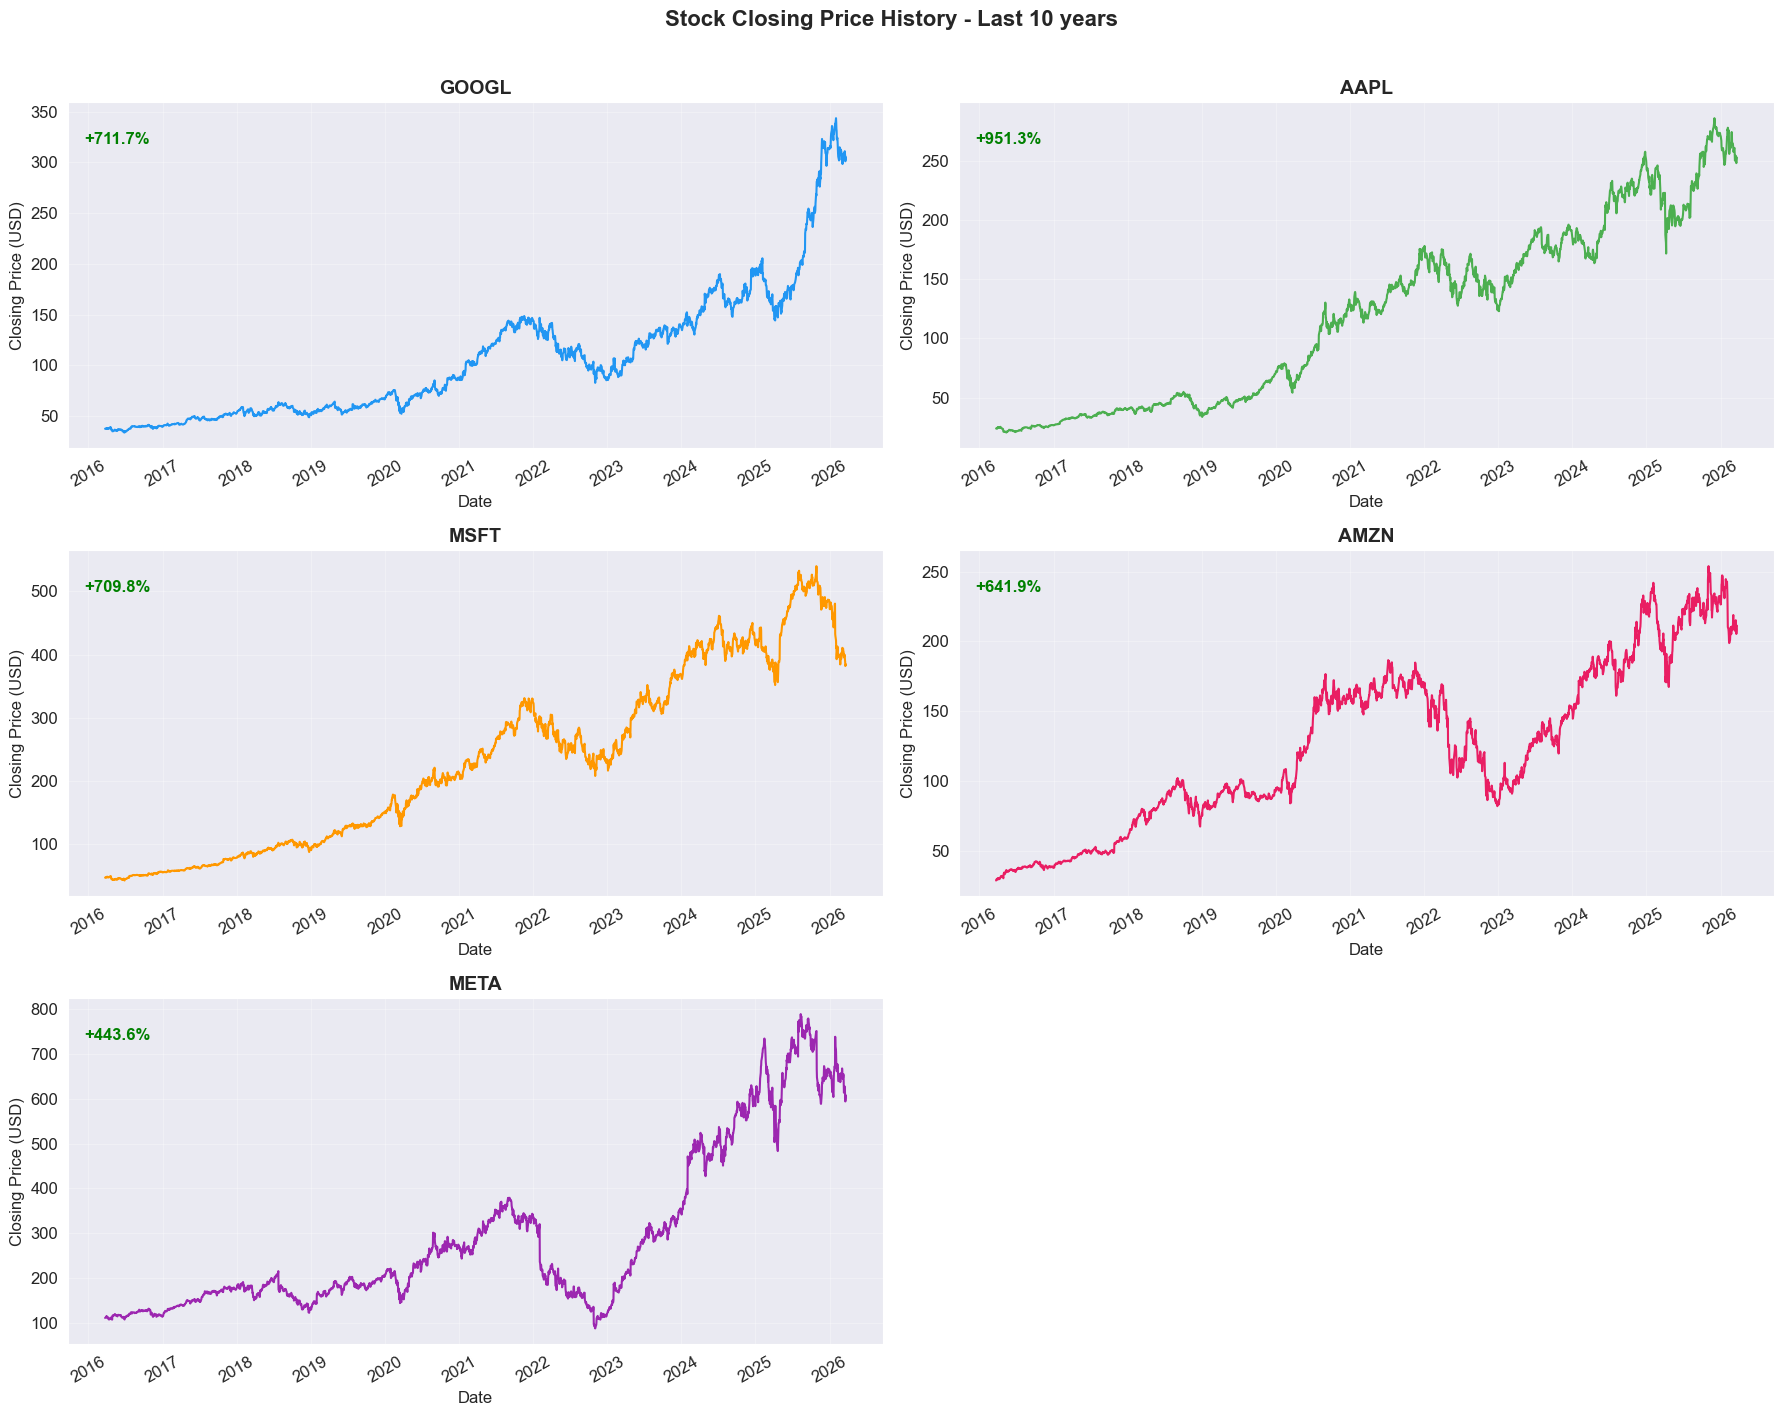

In [11]:
# -- Plot 1: Individual closing price history--

fig, axes = plt.subplots(3, 2, figsize=(18, 14))
fig.suptitle('Stock Closing Price History - Last 10 years', fontsize=16, fontweight='bold', y=1.01)
axes = axes.flatten()

for i, (ticker, color) in enumerate(zip(TICKERS, PALETTE)):
    df = frames[ticker]
    axes[i].plot(df.index, df['Close'], color=color, linewidth=1.5, label=ticker)
    axes[i].set_title(ticker, fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Date')
    axes[i].set_ylabel('Closing Price (USD)')
    axes[i].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    axes[i].tick_params(axis='x', rotation=30)
    
    # Annotate total return
    start_p = df['Close'].iloc[0]
    end_p = df['Close'].iloc[-1]
    pct_chg = ((end_p - start_p) / start_p) * 100
    axes[i].annotate(
        f'+{pct_chg:.1f}%' if pct_chg >= 0 else f'{pct_chg:.1f}%',
        xy=(0.02, 0.88), xycoords='axes fraction', 
        fontsize=12, fontweight='bold',
        color='green' if pct_chg >= 0 else 'red'
    )
    
fig.delaxes(axes[5]) # Remove empty subplot
plt.tight_layout()
plt.savefig('closing_price_history.png', dpi=300, bbox_inches='tight')
plt.show()
    

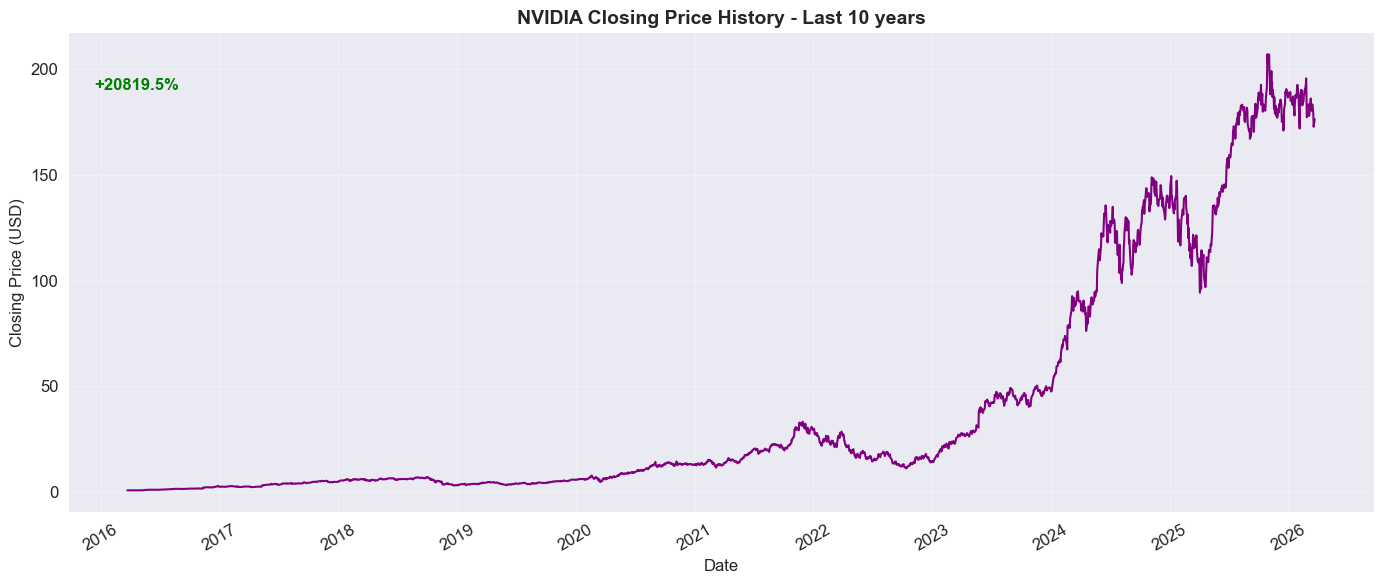

In [12]:
# -- Plot: NVIDIA Closing Price History --

df_nvda = frames['NVDA']

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df_nvda.index, df_nvda['Close'], color='purple', linewidth=1.5, label='NVDA')
ax.set_title('NVIDIA Closing Price History - Last 10 years', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Closing Price (USD)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.tick_params(axis='x', rotation=30)

# Annotate total return
start_p = df_nvda['Close'].iloc[0]
end_p = df_nvda['Close'].iloc[-1]
pct_chg = ((end_p - start_p) / start_p) * 100
ax.annotate(
    f'+{pct_chg:.1f}%' if pct_chg >= 0 else f'{pct_chg:.1f}%',
    xy=(0.02, 0.88), xycoords='axes fraction', 
    fontsize=12, fontweight='bold',
    color='green' if pct_chg >= 0 else 'red'
)

plt.tight_layout()
plt.savefig('nvidia_closing_price_history.png', dpi=300, bbox_inches='tight')
plt.show()

* All the companys took a deep in 2023 and 2025, the stock closing prices went down. What exactly happened?

**Key Questions to ask**
1. What are the macro and micro economic situations affecting the globe or US?
2. Are there other  factors that could have contributed to that?
3. Could it be AI?

Is there a correlation between all this? or was it random or by chance?


In [ ]:
closing_prices = pd.DataFrame(
    {ticker: frames[ticker]['Close'] for ticker in TICKERS}
)
print(closing_prices.head())

In [ ]:
# Plot 2: Normalized closing price history(Base = 100)
normalized = closing_prices / closing_prices.iloc[0] * 100